2026-08-15 18:55:39.631 | INFO     | __main__:model_call_evaluator:70 - grade='好笑' feedback='这是一个很幽默且精准的笑话。它抓住了猫奴与猫之间“主仆关系”的精髓——猫的行为往往令人费解或恼火（推杯子），但人类不仅不怪罪，反而乐在其中。这种对现实生活的解构和反转非常有趣，很容易引起养猫人士的共鸣。'
2026-08-15 18:55:39.632 | WARNING  | __main__:<module>:118 - 超步数量达到最大限制


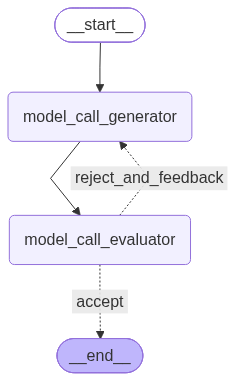

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model_call_generator(model_call_generator)
	model_call_evaluator(model_call_evaluator)
	__end__([<p>__end__</p>]):::last
	__start__ --> model_call_generator;
	model_call_evaluator -. &nbsp;accept&nbsp; .-> __end__;
	model_call_evaluator -. &nbsp;reject_and_feedback&nbsp; .-> model_call_generator;
	model_call_generator --> model_call_evaluator;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [3]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_deepseek import ChatDeepSeek
from pydantic import BaseModel, Field
from loguru import logger
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv(override=True)
from rich import print as rprint

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-3.1-flash-lite",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

# 图状态
class OverAllState(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

# 定义用于结构化输出的 Schema，作为笑话评估依据
class Feedback(BaseModel):
    grade: Literal["好笑", "不好笑"] = Field(
        description="判断这个笑话是否好笑。",
    )
    feedback: str = Field(
        description="如果笑话不好笑，请给出具体的改进建议。",
    )

# 为大模型添加结构化输出能力，定义评估器
evaluator = model.with_structured_output(Feedback)

# 节点
def model_call_generator(state: OverAllState) -> OverAllState:
    """大模型生成笑话"""

    if state.get("feedback"):
        msg = model.invoke(
            f"""
            写一个关于“{state['topic']}”的笑话。

            请参考下面的改进建议：
            {state['feedback']}
            """
        )
    else:
        msg = model.invoke(f"写一个关于“{state['topic']}”的笑话")

    return {"joke": msg.content}


def model_call_evaluator(state: OverAllState) -> OverAllState:
    """大模型评估笑话"""

    grade = evaluator.invoke(
        f"""
        请评估下面这个笑话是否好笑：

        {state['joke']}
        """
    )
    logger.info(grade)
    return {
        "funny_or_not":grade,
        "feedback": grade.feedback,
    }


# 条件边函数：根据评估结果决定结束流程，或者返回笑话生成节点
def route_joke(state: OverAllState) -> Literal["accept", "reject_and_feedback", END]:
    """根据评估结果决定接受笑话或根据反馈重新生成"""

    if state["funny_or_not"] == "好笑":
        return "accept"
    elif state["funny_or_not"] == "不好笑":
        return "reject_and_feedback"
    return END

# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("model_call_generator", model_call_generator)
builder.add_node("model_call_evaluator", model_call_evaluator)

# 添加边，连接各个节点
builder.add_edge(START, "model_call_generator")
builder.add_edge("model_call_generator", "model_call_evaluator")
builder.add_conditional_edges(
    "model_call_evaluator",
    route_joke,
    {
        # route_joke 返回的名称：接下来要执行的节点
        "accept": END,
        "reject_and_feedback": "model_call_generator",
    },
)

# 编译工作流
graph = builder.compile()

# 调用工作流
try:
    state = graph.invoke(
        {"topic": "猫"},
        config={"recursion_limit": 5}
    )

except Exception:
    logger.warning("超步数量达到最大限制")
    state = None

except Exception:
    logger.exception("Graph 执行过程中发生未知错误")
    state = None


if state is not None:
    print(state["joke"])

# 显示工作流图
from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)